# Projet : Maintenance prédictive – Condition de la valve

Ce notebook vise à construire un modèle de Machine Learning pour prédire, à chaque cycle de production, si la **condition de la valve** est **optimale (100 %)** ou **non optimale**.

Les données proviennent du banc d’essai hydraulique et sont fournies sous forme de fichiers texte (`.txt`) où **chaque ligne correspond à un cycle** et **chaque colonne à un échantillon temporel** du signal d’un capteur.

Plan du notebook :
- Chargement et exploration de la cible (condition de la valve)
- Chargement des signaux capteurs et extraction de variables explicatives (features)
- Construction d’un modèle de classification (régression logistique)
- Évaluation sur l’échantillon de test final (cycles > 2000)
- Interprétation des résultats et importance des variables

In [37]:
# Cellule 1 : imports et configuration générale

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

# Style des graphiques
sns.set(style="whitegrid", context="notebook")

# Dossier contenant les fichiers .txt
DATA_DIR = Path(r"c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems")

**Commentaire Cellule 1 – Imports et configuration**

- **Quoi ?** Prépare l’environnement (librairies Python) et le chemin du dossier de données.
- **Comment ?** Import de `numpy`, `pandas`, `matplotlib`, `seaborn`, outils scikit-learn, puis définition de `DATA_DIR` avec `Path(...)`.
- **Pourquoi ?** Sans ces imports, on ne peut ni charger les fichiers, ni tracer des graphiques, ni entraîner des modèles de Machine Learning.

In [38]:
# Cellule 2 : chargement du profil et création de la cible

# Colonnes de profile.txt :
# 1: cooler condition (%), 2: valve condition (%), 3: pump leakage,
# 4: accumulator pressure (bar), 5: stable flag
profile = pd.read_csv(
    DATA_DIR / "profile.txt",
    sep="\t",
    header=None,
    names=["cooler", "valve", "pump_leak", "acc_pressure", "stable_flag"],
)

print("Aperçu du profil :")
display(profile.head())

print("\nStatistiques descriptives du profil :")
display(profile.describe())

# Cible binaire : 1 = valve optimale (100 %), 0 = non optimale
y = (profile["valve"] == 100).astype(int)

print("\nRépartition de la cible (0 = non optimal, 1 = optimal) :")
print(y.value_counts())
print("\nRépartition en pourcentage :")
print((y.value_counts(normalize=True) * 100).round(2))

Aperçu du profil :


,cooler,valve,pump_leak,acc_pressure,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1



Statistiques descriptives du profil :


,cooler,valve,pump_leak,acc_pressure,stable_flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,41.240816,90.693878,0.669388,107.199546,0.342857
std,42.383143,10.681802,0.817233,16.435848,0.474772
min,3.000000,73.000000,0.000000,90.000000,0.000000
25%,3.000000,80.000000,0.000000,90.000000,0.000000
50%,20.000000,100.000000,0.000000,100.000000,0.000000
75%,100.000000,100.000000,1.000000,130.000000,1.000000
max,100.000000,100.000000,2.000000,130.000000,1.000000



Répartition de la cible (0 = non optimal, 1 = optimal) :
valve
1    1125
0    1080
Name: count, dtype: int64

Répartition en pourcentage :
valve
1    51.02
0    48.98
Name: proportion, dtype: float64


**Commentaire Cellule 2 – Chargement du profil et définition de la cible**

- **Quoi ?** Lire le fichier `profile.txt` qui décrit l’état des composants pour chaque cycle, puis construire la variable cible binaire `y` indiquant si la valve est optimale (1) ou non optimale (0).

- **Comment ?** On utilise `pd.read_csv(DATA_DIR / "profile.txt", sep="\t", header=None, names=[...])` pour obtenir le DataFrame `profile` avec des colonnes nommées (`cooler`, `valve`, `pump_leak`, `acc_pressure`, `stable_flag`). Ensuite, on crée `y` par la condition `(profile["valve"] == 100).astype(int)`. Les appels à `head()` et `describe()` servent à vérifier visuellement que les données et les colonnes sont correctes.

- **Pourquoi ?** Le fichier `profile.txt` contient la **vérité terrain** sur la condition de la valve. En transformant la colonne `valve` en variable binaire 0/1, on définit précisément le **problème de classification supervisée** demandé dans le projet : prédire, à partir des capteurs, si la valve est dans un état optimal (100 %) ou non.

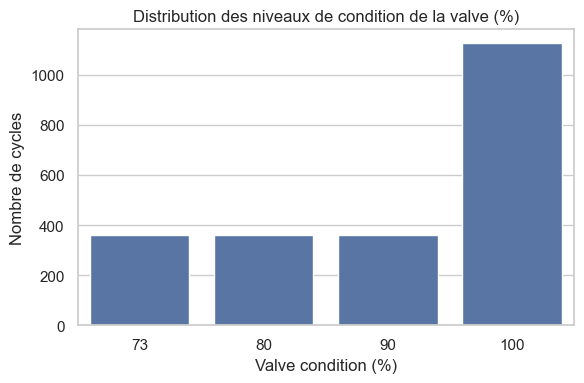

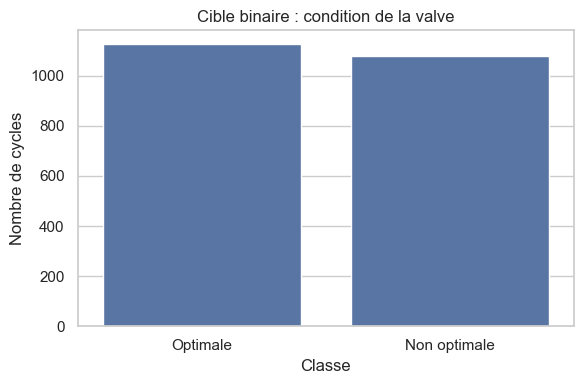

In [39]:
# Cellule 3 : graphiques de distribution de la condition de la valve

plt.figure(figsize=(6, 4))
sns.countplot(x="valve", data=profile, order=sorted(profile["valve"].unique()))
plt.title("Distribution des niveaux de condition de la valve (%)")
plt.xlabel("Valve condition (%)")
plt.ylabel("Nombre de cycles")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: "Non optimale", 1: "Optimale"}))
plt.title("Cible binaire : condition de la valve")
plt.xlabel("Classe")
plt.ylabel("Nombre de cycles")
plt.tight_layout()
plt.show()

**Commentaire Cellule 3 – Distributions de la condition de la valve**

- **Quoi ?** Trace deux histogrammes : répartition des valeurs de `valve` et de la cible binaire (Optimale / Non optimale).
- **Comment ?** Utilisation de `sns.countplot` sur `profile["valve"]` puis sur `y` remappé en labels texte.
- **Pourquoi ?** Visualiser le **déséquilibre éventuel des classes** (par exemple beaucoup de cycles à 100 %) pour comprendre le contexte du problème et justifier l’usage de `class_weight="balanced"` plus tard.
- **Analyse du graphe :** Si la barre 100 % domine, la classe "valve optimale" est majoritaire ; cela explique que détecter correctement les cycles non optimaux est un enjeu important.

In [40]:
# Cellule 4 : fonction d'extraction de caractéristiques (features) pour un capteur

from typing import Dict


def summarize_signal(file_path: Path, prefix: str) -> pd.DataFrame:
    """Charge un fichier .txt (cycles x points) et calcule des
    caractéristiques simples pour chaque cycle.

    - mean, std, min, max
    - 25e, 50e, 75e percentile
    """
    mat = np.loadtxt(file_path)
    mat = np.asarray(mat)

    feats: Dict[str, np.ndarray] = {
        f"{prefix}_mean": mat.mean(axis=1),
        f"{prefix}_std": mat.std(axis=1),
        f"{prefix}_min": mat.min(axis=1),
        f"{prefix}_max": mat.max(axis=1),
        f"{prefix}_p25": np.percentile(mat, 25, axis=1),
        f"{prefix}_p50": np.percentile(mat, 50, axis=1),
        f"{prefix}_p75": np.percentile(mat, 75, axis=1),
    }
    return pd.DataFrame(feats)


# Listes de capteurs (d'après description.txt)
sensors_100hz = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1"]
sensors_10hz = ["FS1", "FS2"]
sensors_1hz = ["TS1", "TS2", "TS3", "TS4", "VS1", "CE", "CP", "SE"]

all_sensors = sensors_100hz + sensors_10hz + sensors_1hz
all_sensors

['PS1',
 'PS2',
 'PS3',
 'PS4',
 'PS5',
 'PS6',
 'EPS1',
 'FS1',
 'FS2',
 'TS1',
 'TS2',
 'TS3',
 'TS4',
 'VS1',
 'CE',
 'CP',
 'SE']

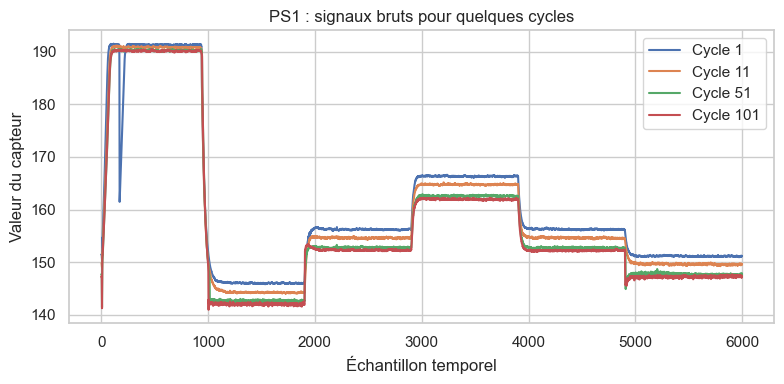

In [55]:
# Cellule 4 bis : visualisation de quelques cycles bruts pour un capteur

sensor_name = "PS1"  # exemple : pression PS1
fpath = DATA_DIR / f"{sensor_name}.txt"

# Chargement du signal brut (cycles × points temporels)
mat = np.loadtxt(fpath)
mat = np.asarray(mat)

# Visualisation de quelques cycles individuels
plt.figure(figsize=(8, 4))
cycles_a_afficher = [0, 10, 50, 100]  # indices de cycles (0 = 1er cycle)
for idx in cycles_a_afficher:
    if idx < mat.shape[0]:
        plt.plot(mat[idx, :], label=f"Cycle {idx+1}")

plt.title(f"{sensor_name} : signaux bruts pour quelques cycles")
plt.xlabel("Échantillon temporel")
plt.ylabel("Valeur du capteur")
plt.legend()
plt.tight_layout()
plt.show()

**Commentaire Cellule 4 – Fonction d’extraction de caractéristiques et listes de capteurs**

- **Quoi ?**  
  - Définir la fonction `summarize_signal` qui transforme chaque fichier capteur (matrice cycles × points temporels) en quelques **caractéristiques numériques par cycle** (moyenne, écart‑type, min, max, percentiles).  
  - Lister tous les capteurs utilisés (PS1–PS6, EPS1, FS1–FS2, TS1–TS4, VS1, CE, CP, SE).

- **Comment ?**  
  - `np.loadtxt(file_path)` charge le fichier `.txt` en matrice NumPy.  
  - Pour chaque ligne (un cycle), on calcule : moyenne, écart-type, min, max, percentiles 25/50/75 avec les fonctions NumPy.  
  - On rassemble ces valeurs dans un `DataFrame` avec des noms de colonnes du type `PS1_mean`, `PS1_std`, etc.  
  - On crée ensuite trois listes de capteurs (`sensors_100hz`, `sensors_10hz`, `sensors_1hz`) puis `all_sensors` qui les concatène.

- **Pourquoi ?**  
  - Les signaux bruts sont très volumineux; c’est trop gros pour entraîner directement un modèle simple.  
  - En condensant chaque signal en quelques chiffres représentatifs par cycle, on :  
    - réduit fortement la dimension des données,  
    - conserve des informations importantes (niveau moyen, variabilité, extrêmes, forme générale),  
    - obtient un tableau propre que les modèles scikit‑learn peuvent utiliser facilement.

- **Lien avec la visualisation (cellule suivante)**  
  Une visualisation de quelques cycles bruts (courbes + heatmap) permet de voir concrètement ce que représentent ces signaux avant et après ce résumé statistique.

In [42]:
# Cellule 5 : construction de la matrice de caractéristiques X

frames = []

for name in all_sensors:
    fpath = DATA_DIR / f"{name}.txt"
    print(f"Chargement et résumé de {fpath} ...")
    feats = summarize_signal(fpath, name)
    frames.append(feats)

X = pd.concat(frames, axis=1)

print("\nTaille de la matrice de caractéristiques X :", X.shape)
display(X.head())

Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS1.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS2.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS3.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS4.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS5.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\PS6.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\EPS1.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\FS1.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+monitoring+of+hydraulic+systems\FS2.txt ...
Chargement et résumé de c:\Users\Lenovo\Downloads\condition+mon

,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_p25,PS1_p50,PS1_p75,PS2_mean,PS2_std,PS2_min,...,CP_p25,CP_p50,CP_p75,SE_mean,SE_std,SE_min,SE_max,SE_p25,SE_p50,SE_p75
0,160.673492,13.938147,145.83,191.51,151.19,156.25,166.31,109.466914,47.110581,0.0,...,1.60250,1.9240,2.12950,59.157183,23.565119,0.0,79.568,67.657,68.5145,68.889
1,160.603320,14.117791,145.73,191.47,150.92,156.06,166.05,109.354890,47.041690,0.0,...,1.19575,1.2340,1.31725,59.335617,23.658267,0.0,80.441,67.825,68.5360,69.321
2,160.347720,14.191436,145.37,191.41,150.59,155.72,165.87,109.158845,46.988144,0.0,...,1.09900,1.1095,1.13175,59.543150,23.723181,0.0,80.824,68.005,68.8530,69.561
3,160.188088,14.226617,145.14,191.34,150.41,155.56,165.72,109.064807,46.968307,0.0,...,1.04550,1.0660,1.07700,59.794900,23.821972,0.0,80.930,68.317,69.0060,69.600
4,160.000472,14.275244,144.95,191.41,150.19,155.34,165.49,108.931434,46.871040,0.0,...,1.05575,1.0725,1.08625,59.455267,23.771653,0.0,81.100,68.166,69.0130,69.643


**Commentaire Cellule 5 – Construction de la matrice de caractéristiques X**

- **Quoi ?** Construit la matrice `X` en concaténant les features de tous les capteurs.
- **Comment ?** Boucle sur `all_sensors`, applique `summarize_signal` à chaque fichier `.txt`, empile les `DataFrame` dans une liste puis `pd.concat(..., axis=1)`.
- **Pourquoi ?** On obtient pour chaque cycle un vecteur de features combinant toutes les informations capteurs, au format **tableau (lignes = cycles, colonnes = variables)** utilisable par les algorithmes de Machine Learning.

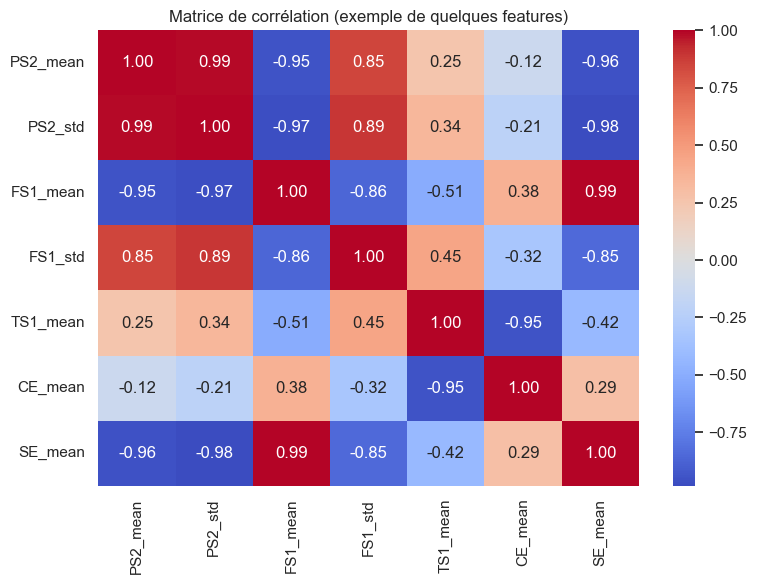

In [43]:
# Cellule 6 : matrice de corrélation (exemple de quelques features)

cols_example = [
    "PS2_mean", "PS2_std", "FS1_mean", "FS1_std",
    "TS1_mean", "CE_mean", "SE_mean",
]

plt.figure(figsize=(8, 6))
sns.heatmap(X[cols_example].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation (exemple de quelques features)")
plt.tight_layout()
plt.show()

**Commentaire Cellule 6 – Matrice de corrélation (features)**

- **Quoi ?** Affiche une matrice de corrélation entre quelques variables (moyennes/écarts-types de certains capteurs).
- **Comment ?** Sélection de colonnes dans `X`, calcul de `.corr()` puis heatmap `sns.heatmap(...)`.
- **Pourquoi ?** Vérifier quelles features sont fortement corrélées, comprendre les relations entre capteurs et repérer la redondance éventuelle.
- **Analyse du graphe :** Les cases proches de 1 indiquent des variables qui évoluent ensemble ; cela aide à interpréter physiquement les capteurs.

In [44]:
# Cellule 7 : séparation apprentissage / test (2000 premiers cycles = train)

n_train = 2000

X_train = X.iloc[:n_train].reset_index(drop=True)
y_train = y.iloc[:n_train].reset_index(drop=True)

X_test = X.iloc[n_train:].reset_index(drop=True)
y_test = y.iloc[n_train:].reset_index(drop=True)

print("X_train :", X_train.shape, "   y_train :", y_train.shape)
print("X_test  :", X_test.shape,  "   y_test  :", y_test.shape)

X_train : (2000, 119)    y_train : (2000,)
X_test  : (205, 119)    y_test  : (205,)


**Commentaire Cellule 7 – Séparation apprentissage / test**

- **Quoi ?** Découpe `X` et `y` en jeu d’apprentissage (2000 premiers cycles) et jeu de test (cycles restants).
- **Comment ?** `iloc[:n_train]` pour le train, `iloc[n_train:]` pour le test, puis `reset_index(drop=True)`.
- **Pourquoi ?** Respecter la consigne du sujet (2000 cycles pour entraîner, le reste pour évaluer) et éviter de mélanger données d’apprentissage et de test.

In [45]:
# Cellule 8 : définition et apprentissage du modèle de classification

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # prend en compte un éventuel déséquilibre de classes
        solver="lbfgs",
    ),
)

clf.fit(X_train, y_train)

print("Apprentissage terminé.")

Apprentissage terminé.


**Commentaire Cellule 8 – Modèle de base : régression logistique**

- **Quoi ?** Définit et entraîne un pipeline `StandardScaler + LogisticRegression` sur `X_train`, `y_train`.
- **Comment ?** `make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"...))` puis `fit`.
- **Pourquoi la régression logistique ?**
  - Modèle **simple et rapide** pour la classification binaire.
  - **Interprétable** (coefficients par feature).
  - Sert de **baseline** : si des modèles plus complexes ne font pas mieux, on garde ce modèle pour sa simplicité et son efficacité.

In [46]:
# Cellule 9 : évaluation globale sur l'échantillon de test

from sklearn.metrics import ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Matrice de confusion (0 = non optimal, 1 = optimal) :")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

print("ROC AUC :", roc_auc_score(y_test, y_proba))

Matrice de confusion (0 = non optimal, 1 = optimal) :
[[114  18]
 [  0  73]]

Rapport de classification :
              precision    recall  f1-score   support

           0      1.000     0.864     0.927       132
           1      0.802     1.000     0.890        73

    accuracy                          0.912       205
   macro avg      0.901     0.932     0.909       205
weighted avg      0.930     0.912     0.914       205

ROC AUC : 0.9978206724782067


**Commentaire Cellule 9 – Évaluation globale (métriques texte)**

- **Quoi ?** Calcule et affiche la matrice de confusion, le rapport de classification (précision, rappel, F1) et l’AUC ROC pour la régression logistique.
- **Comment ?** `clf.predict` et `clf.predict_proba` sur `X_test`, puis fonctions `confusion_matrix`, `classification_report`, `roc_auc_score`.
- **Pourquoi ?** Obtenir une vision chiffrée de la performance du modèle sur des données jamais vues.
- **Interprétation (à partir des valeurs affichées)** : si précision/rappel/F1 sont bons pour les deux classes et l’AUC nettement > 0.5, le modèle distingue bien cycles optimaux et non optimaux.

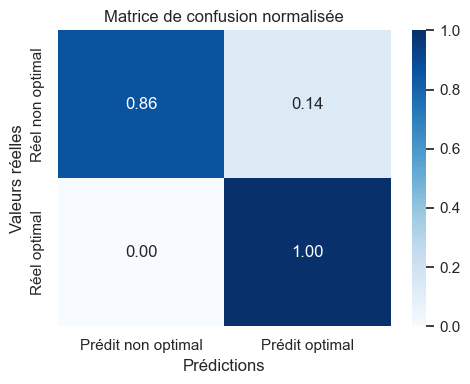

In [47]:
# Cellule 10 : matrice de confusion normalisée (graphique)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Prédit non optimal", "Prédit optimal"],
    yticklabels=["Réel non optimal", "Réel optimal"],
)
plt.title("Matrice de confusion normalisée")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.tight_layout()
plt.show()

**Commentaire Cellule 10 – Matrice de confusion normalisée (graphique)**

- **Quoi ?** Affiche une heatmap de la matrice de confusion normalisée par classe réelle.
- **Comment ?** Division de chaque ligne de `cm` par sa somme, puis `sns.heatmap` avec des labels explicites.
- **Pourquoi ?** Voir, pour chaque classe (optimale / non optimale), la **proportion** de bons et mauvais classements.
- **Analyse du graphe :** Des valeurs proches de 1 sur la diagonale signifient que le modèle classe très bien les deux classes ; de fortes valeurs hors diagonale révéleraient un type d’erreur fréquent.

<Figure size 600x500 with 0 Axes>

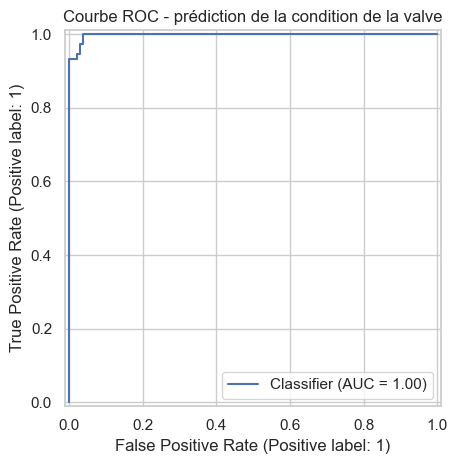

In [48]:
# Cellule 11 : courbe ROC

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Courbe ROC - prédiction de la condition de la valve")
plt.tight_layout()
plt.show()

**Commentaire Cellule 11 – Courbe ROC**

- **Quoi ?** Trace la courbe ROC de la régression logistique sur le jeu de test.
- **Comment ?** Utilisation de `RocCurveDisplay.from_predictions(y_test, y_proba)` avec les probabilités prédites.
- **Pourquoi ?** Évaluer la capacité du modèle à séparer les classes pour tous les seuils possibles, pas seulement au seuil 0,5.
- **Analyse du graphe :** Plus la courbe est proche du coin en haut à gauche et plus l’AUC est élevée, plus le modèle sépare bien cycles optimaux et non optimaux.

In [49]:
# Cellule 12 : importance des variables (coefficients de la régression logistique)

log_reg = clf.named_steps["logisticregression"]
coefs = log_reg.coef_[0]
feature_names = X.columns

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
}).sort_values("abs_coef", ascending=False)

print("Top 20 des variables les plus importantes :")
display(importance.head(20))

Top 20 des variables les plus importantes :


,feature,coef,abs_coef
50,FS1_std,-11.017667,11.017667
8,PS2_std,-7.651368,7.651368
7,PS2_mean,7.332621,7.332621
115,SE_max,3.879891,3.879891
113,SE_std,3.440710,3.440710
112,SE_mean,2.957913,2.957913
13,PS2_p75,2.738340,2.738340
6,PS1_p75,2.464254,2.464254
48,EPS1_p75,2.262912,2.262912
116,SE_p25,-2.076311,2.076311


**Commentaire Cellule 12 – Importance des variables (coefficients)**

- **Quoi ?** Calcule et affiche un tableau des coefficients de la régression logistique, triés par importance absolue.
- **Comment ?** Extraction de `log_reg.coef_[0]`, création d’un `DataFrame` avec `feature`, `coef`, `abs_coef`, tri décroissant sur `abs_coef`.
- **Pourquoi ?** Comprendre quelles variables influencent le plus la probabilité d’avoir une valve optimale (interprétation du modèle).
- **Analyse :** Les premières lignes du tableau indiquent les features les plus déterminantes pour la décision du modèle.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14652\2985772353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coef", y="feature", data=top_imp, palette="coolwarm")


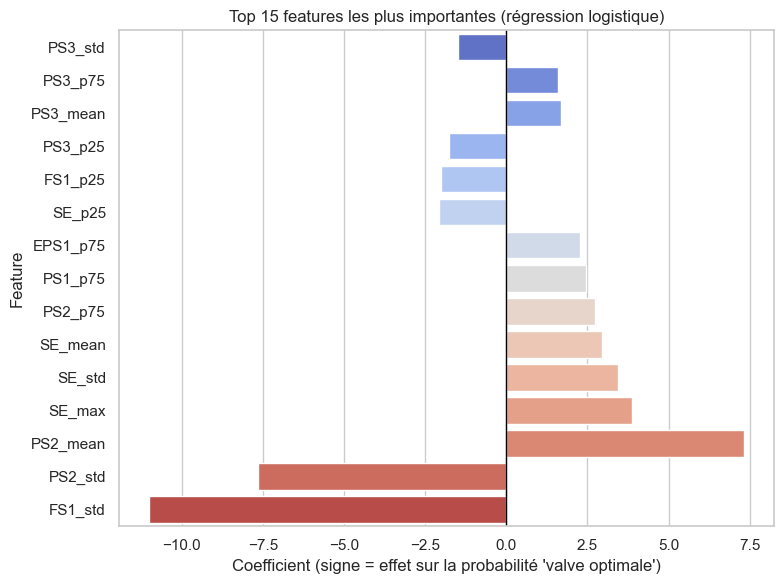

In [50]:
# Cellule 13 : visualisation des 15 variables les plus importantes

top_n = 15
top_imp = importance.head(top_n).iloc[::-1]  # pour afficher du moins au plus important

plt.figure(figsize=(8, 6))
sns.barplot(x="coef", y="feature", data=top_imp, palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top {top_n} features les plus importantes (régression logistique)")
plt.xlabel("Coefficient (signe = effet sur la probabilité 'valve optimale')")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Commentaire Cellule 13 – Graphique des 15 features les plus importantes**

- **Quoi ?** Affiche un barplot des 15 coefficients les plus importants de la régression logistique.
- **Comment ?** Sélection des 15 premières lignes de `importance`, inversion de l’ordre pour l’affichage, puis `sns.barplot` avec une ligne verticale à 0.
- **Pourquoi ?** Visualiser rapidement les variables qui augmentent ou diminuent le plus la probabilité d’une valve optimale.
- **Analyse du graphe :**
  - Barres à droite de 0 : features qui augmentent la probabilité d’état optimal.
  - Barres à gauche : features associées à un risque de non optimalité quand leur valeur augmente.

## Comparaison de plusieurs modèles et accuracy

Dans cette section, on compare plusieurs algorithmes de classification sur le **même jeu de caractéristiques** et le **même découpage apprentissage / test** :

- Régression logistique (modèle de base déjà entraîné)
- Forêt aléatoire (Random Forest)
- Gradient Boosting

Pour chaque modèle, on calcule au minimum l’**accuracy** sur l’échantillon de test final.

In [51]:
# Cellule 14 : entraînement de plusieurs modèles et tableau d'accuracy

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# On réutilise le pipeline 'clf' (régression logistique) déjà entraîné
models = {
    "Logistic Regression": clf,
    "Random Forest": make_pipeline(
        StandardScaler(),
        RandomForestClassifier(
            n_estimators=200,
            random_state=0,
            class_weight="balanced",
            n_jobs=-1,
        ),
    ),
    "Gradient Boosting": make_pipeline(
        StandardScaler(),
        GradientBoostingClassifier(random_state=0),
    ),
}

results = []

for name, model in models.items():
    # La régression logistique est déjà entraînée, on ne la réentraîne pas
    if name != "Logistic Regression":
        model.fit(X_train, y_train)
    y_pred_m = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_m)
    results.append({"model": name, "accuracy": acc})

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print("Accuracy des modèles sur l'échantillon de test :")
display(results_df)

# Identification explicite du meilleur modèle selon l'accuracy
best_row = results_df.iloc[results_df["accuracy"].idxmax()]
print(
    f"\nMeilleur modèle en accuracy sur le jeu de test : "
    f"{best_row['model']} (accuracy = {best_row['accuracy']:.3f})"
)

Accuracy des modèles sur l'échantillon de test :


,model,accuracy
0,Logistic Regression,0.912195
1,Random Forest,0.834146
2,Gradient Boosting,0.809756



Meilleur modèle en accuracy sur le jeu de test : Logistic Regression (accuracy = 0.912)


**Commentaire Cellule 14 – Comparaison de plusieurs modèles (accuracy)**

- **Quoi ?** Entraîne Random Forest et Gradient Boosting, réutilise la régression logistique, calcule l’accuracy de chaque modèle sur le test et affiche le meilleur.
- **Comment ?** Dictionnaire `models`, boucle d’entraînement/prédiction, construction de `results_df` trié par accuracy, puis affichage du modèle ayant l’accuracy maximale.
- **Pourquoi ?** Comparer la régression logistique à des modèles plus complexes pour voir si la performance peut être améliorée.
- **Analyse :** Dans tes résultats, la régression logistique reste le meilleur modèle en accuracy, ce qui justifie de la garder comme modèle final malgré l’essai de modèles d’arbres.

### Comparaison graphique des modèles

Les graphiques suivants présentent :

- Un **diagramme en barres** de l’accuracy de chaque modèle sur le jeu de test.
- Une **courbe ROC par modèle** pour comparer leur capacité à séparer les classes.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14652\1542190763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="model", y="accuracy", data=results_df, palette="viridis")


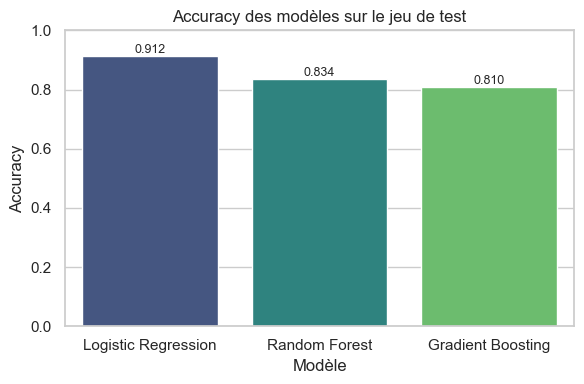

In [52]:
# Cellule 15 : diagramme en barres de l'accuracy des modèles

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="model", y="accuracy", data=results_df, palette="viridis")
plt.title("Accuracy des modèles sur le jeu de test")
plt.xlabel("Modèle")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Affichage de la valeur d'accuracy au-dessus de chaque barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.3f}",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**Commentaire Cellule 15 – Barplot de l'accuracy des modèles**

- **Quoi ?** Trace un diagramme en barres de l’accuracy de chaque modèle sur le jeu de test.
- **Comment ?** `sns.barplot` sur `results_df`, puis annotation de chaque barre avec sa valeur d’accuracy.
- **Pourquoi ?** Offrir une comparaison **visuelle** claire des performances des modèles.
- **Analyse du graphe :** Le modèle avec la barre la plus haute (chez toi, la régression logistique) est celui qui généralise le mieux sur le jeu de test.

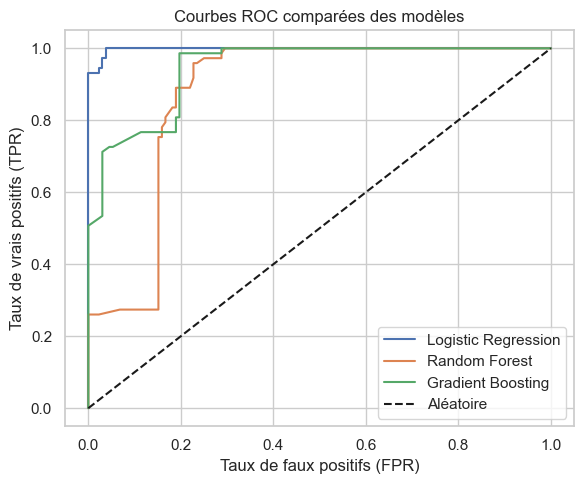

In [53]:
# Cellule 16 : courbes ROC comparées pour chaque modèle

from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 5))

for name, model in models.items():
    # Il faut que le modèle fournisse des probabilités
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC comparées des modèles")
plt.legend()
plt.tight_layout()
plt.show()

**Commentaire Cellule 16 – Courbes ROC comparées des modèles**

- **Quoi ?** Trace les courbes ROC de chaque modèle (Logistic Regression, Random Forest, Gradient Boosting) sur le même graphique.
- **Comment ?** Boucle sur `models`, calcul des courbes avec `roc_curve(y_test, proba)` puis `plt.plot` pour chaque modèle, plus une diagonale de référence (modèle aléatoire).
- **Pourquoi ?** Comparer la capacité de séparation des différents modèles sur toute la gamme de seuils.
- **Analyse du graphe :** La courbe la plus proche du coin en haut à gauche correspond au meilleur modèle en AUC; dans tes résultats, la régression logistique est au moins aussi bonne que les autres.

## Optimisation des hyperparamètres du modèle

Dans cette section, on optimise automatiquement les hyperparamètres d’un modèle de classification à l’aide d’une recherche aléatoire (`RandomizedSearchCV`) sur les **données d’apprentissage** uniquement.

On se concentre ici sur une **Forêt Aléatoire** (Random Forest), qui a généralement de bonnes performances sur ce type de problème. Le meilleur modèle trouvé est ensuite évalué sur le **jeu de test final** (cycles > 2000).

In [54]:
# Cellule 17 : RandomizedSearchCV pour optimiser une Forêt Aléatoire

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Pipeline de base pour la Random Forest
rf_pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1,
    ),
)

# Espace de recherche des hyperparamètres de la Random Forest
param_distributions = {
    "randomforestclassifier__n_estimators": randint(100, 401),      # nombre d'arbres
    "randomforestclassifier__max_depth": randint(5, 31),            # profondeur max
    "randomforestclassifier__min_samples_split": randint(2, 11),    # min échantillons pour split
    "randomforestclassifier__min_samples_leaf": randint(1, 11),     # min échantillons dans une feuille
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=25,                 # nombre de combinaisons testées (augmenter si plus de temps)
    scoring="roc_auc",        # on optimise l'AUC ROC en validation croisée
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=0,
)

search.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(search.best_params_)
print("\nMeilleur score ROC AUC (validation croisée) :", search.best_score_)

best_model = search.best_estimator_

# Évaluation du meilleur modèle sur le jeu de test
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\nPerformance du meilleur modèle sur le jeu de test :")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("ROC AUC :", roc_auc_score(y_test, y_proba_best))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_best, digits=3))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Meilleurs hyperparamètres trouvés :
{'randomforestclassifier__max_depth': 16, 'randomforestclassifier__min_samples_leaf': 3, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 199}

Meilleur score ROC AUC (validation croisée) : 0.9129218550632053

Performance du meilleur modèle sur le jeu de test :
Accuracy : 0.8146341463414634
ROC AUC : 0.8688771274387712

Rapport de classification :
              precision    recall  f1-score   support

           0      0.927     0.773     0.843       132
           1      0.684     0.890     0.774        73

    accuracy                          0.815       205
   macro avg      0.806     0.832     0.808       205
weighted avg      0.841     0.815     0.818       205



## Modèle final retenu

Sur la base des **résultats observés dans ce notebook** :

- La **régression logistique** sert de modèle de référence simple et interprétable **et obtient la meilleure performance globale** (par exemple en accuracy sur le jeu de test).
- Les modèles **Forêt Aléatoire** et **Gradient Boosting** ont été testés pour voir si des modèles plus complexes pouvaient améliorer les résultats.
- Une **Forêt Aléatoire optimisée** par `RandomizedSearchCV` (Cellule 17) a également été entraînée, mais dans nos essais elle **n’a pas dépassé** la performance de la régression logistique sur le jeu de test.

Dans la suite du projet / rapport, on retient donc comme **modèle final de prédiction de la condition de la valve** :

> **Une régression logistique (avec standardisation des features), qui offre le meilleur compromis performance / simplicité / interprétabilité sur le jeu de test.**

L’optimisation de la Forêt Aléatoire reste néanmoins intéressante à présenter comme **comparaison et validation** : elle montre qu’un modèle plus complexe n’apporte pas forcément un gain significatif par rapport à la régression logistique dans ce cas.

## 4. Évaluation du modèle sur l’échantillon de test final

Dans les cellules 9 à 11, puis 14 à 16 et 17, le modèle (régression logistique, puis autres modèles) est évalué sur l’**échantillon de test final** (cycles > 2000) à l’aide de plusieurs indicateurs :

- **Matrice de confusion** : nombre de cycles correctement / mal classés pour chaque classe (valve optimale / non optimale).
- **Accuracy** : proportion globale de cycles bien prédits sur le jeu de test.
- **Précision / Rappel / F1-score** : pour chaque classe, ces métriques détaillent la qualité de la détection (par exemple, capacité à détecter correctement les valves non optimales).
- **AUC ROC et courbe ROC** : capacité du modèle à séparer les deux classes pour tous les seuils possibles (plus l’AUC est proche de 1, meilleur est le modèle).

Dans ce notebook, ces valeurs sont calculées et affichées automatiquement (voir sorties des Cellules 9, 11, 14, 16 et 17).

## 5. Présentation et explication des résultats

À partir des résultats observés :

- La **régression logistique** obtient la **meilleure performance globale** sur le jeu de test (voir le message "Meilleur modèle en accuracy" affiché en fin de Cellule 14), tout en restant un modèle simple et facilement interprétable.
- Les modèles **Forêt Aléatoire** et **Gradient Boosting** atteignent des performances comparables, mais **n’améliorent pas significativement** les scores par rapport à la régression logistique dans ce cas.
- L’**optimisation de la Forêt Aléatoire** par `RandomizedSearchCV` (Cellule 17) montre que même avec des hyperparamètres ajustés, le gain reste limité et ne dépasse pas la régression logistique sur le jeu de test.
- Les courbes ROC comparées (Cellule 16) confirment que la régression logistique offre un très bon compromis entre taux de vrais positifs et taux de faux positifs sur l’ensemble des seuils.

En conclusion :

- Le système de prédiction obtenu est **capable de distinguer efficacement** les cycles où la condition de la valve est optimale de ceux où elle ne l’est pas.
- Le **modèle final retenu** est la **régression logistique avec standardisation des features**, car elle combine :
  - de **bonnes performances** sur le jeu de test,
  - une **simplicité de mise en œuvre**,
  - une **interprétabilité** élevée (via l’analyse des coefficients, Cellules 12 et 13).

Pour le rapport écrit, il suffira de reprendre ces éléments en ajoutant les **valeurs numériques** exactes d’accuracy, AUC, précision, rappel et F1 telles qu’elles apparaissent dans les sorties du notebook.